# seaborn `tip` 변수 분석

- `tips` 데이터셋의 `tip` 분포를 시각화하고 평균과 분산을 확인합니다.
- 평균의 함정을 간단히 확인한 뒤, 3가지 표본추출 방법을 비교합니다.


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


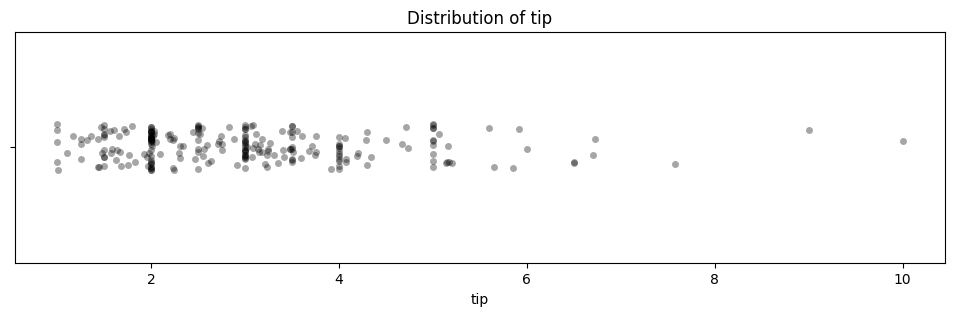

In [18]:
plt.figure(figsize=(12, 3))
sns.stripplot(data=tips, x='tip', color='black', alpha=0.35)
plt.title('Distribution of tip')
plt.xlabel('tip')
plt.show()


In [19]:
tip_mean = tips['tip'].mean()
tip_variance = tips['tip'].var()
tip_median = tips['tip'].median()
tip_skew = tips['tip'].skew()

summary_df = pd.DataFrame({
    'mean': [tip_mean],
    'median': [tip_median],
    'variance': [tip_variance],
    'skewness': [tip_skew],
})
summary_df.round(3)


,mean,median,variance,skewness
0,2.998,2.9,1.914,1.465


## 해석

- `tip`은 오른쪽 꼬리가 긴 분포입니다.
- 큰 팁(예: 7~10달러 부근)이 소수 존재해서 평균이 중앙값보다 약간 커집니다.
- 분산이 0에 가깝지 않으므로 팁 값이 평균 주변에만 모여 있지 않고 꽤 퍼져 있습니다.


In [20]:
# 상위 5% 큰 팁을 제거했을 때 평균이 얼마나 달라지는지 확인
upper_cut = tips['tip'].quantile(0.95)
trimmed_mean = tips.loc[tips['tip'] <= upper_cut, 'tip'].mean()

pd.DataFrame({
    'original_mean': [tip_mean],
    'trimmed_mean(95%)': [trimmed_mean],
    'median': [tip_median],
}).round(3)


,original_mean,trimmed_mean(95%),median
0,2.998,2.789,2.9


## 평균의 함정

- 평균은 이상치의 영향을 크게 받습니다.
- `tips`의 경우 일부 큰 팁 때문에 평균이 올라가지만, 대부분의 관측치는 중앙값 근처에 있습니다.
- 따라서 분포가 치우쳐 있을 때는 평균만 보지 말고 중앙값, 분위수, 분산도 함께 봐야 합니다.


In [21]:
population = tips.copy()
sample_size = 60

def simple_random_sampling(data, n):
    return data.sample(n=n, random_state=42)

def systematic_sampling(data, n):
    step = len(data) // n
    indices = np.arange(0, len(data), step)[:n]
    return data.iloc[indices]

def stratified_sampling(data, group_col, n):
    ratios = data[group_col].value_counts(normalize=True)
    pieces = []
    assigned = 0
    groups = list(ratios.index)

    for group in groups[:-1]:
        size = max(1, round(ratios[group] * n))
        assigned += size
        piece = data[data[group_col] == group].sample(n=size, random_state=42)
        pieces.append(piece)

    last_group = groups[-1]
    last_size = n - assigned
    pieces.append(data[data[group_col] == last_group].sample(n=last_size, random_state=42))
    return pd.concat(pieces).sort_index()

samples = {
    'simple_random': simple_random_sampling(population, sample_size),
    'systematic': systematic_sampling(population, sample_size),
    'stratified_by_day': stratified_sampling(population, 'day', sample_size),
}


In [22]:
population_mean = population['tip'].mean()
population_variance = population['tip'].var()

comparison_rows = []
for name, sample in samples.items():
    sample_mean = sample['tip'].mean()
    sample_variance = sample['tip'].var()
    comparison_rows.append({
        'method': name,
        'sample_mean': sample_mean,
        'sample_variance': sample_variance,
        'mean_error': abs(sample_mean - population_mean),
        'variance_error': abs(sample_variance - population_variance),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(['mean_error', 'variance_error'])
comparison_df.round(3)


,method,sample_mean,sample_variance,mean_error,variance_error
1,systematic,3.039,1.958,0.041,0.044
2,stratified_by_day,3.057,2.539,0.059,0.625
0,simple_random,2.715,1.277,0.283,0.637


In [23]:
comparison_df["total_error"] = comparison_df["mean_error"] + comparison_df["variance_error"]
best_method = comparison_df.sort_values("total_error").iloc[0]["method"]
print(f'Population mean: {population_mean:.3f}')
print(f'Population variance: {population_variance:.3f}')
print(f'Best method in this run: {best_method}')


Population mean: 2.998
Population variance: 1.914
Best method in this run: systematic


## 표본추출 비교 결론

- 이 실행에서는 `systematic` 표본이 모집단 평균과 분산에 가장 가깝게 나왔습니다.
- `simple random`은 무작위성은 좋지만, 이번 표본에서는 분산을 다소 작게 추정했습니다.
- `stratified_by_day`는 요일 비율을 유지한다는 장점이 있지만, 이번 표본에서는 분산이 더 크게 나왔습니다.
- 따라서 **이번 데이터와 이번 추출 결과만 보면 systematic sampling이 가장 적합**하다고 볼 수 있습니다.
- 다만 일반적으로는 데이터 순서에 주기성이 있을 수 있으므로, 실제 분석에서는 층 정보가 중요하면 층화추출도 좋은 선택입니다.
